**Mode:** diagnostic · **Stage:** explore · **Status:** answered  
*ADLC §3 header — characterises signal-target relationship geometry before lens entry.*

# EDA-3 — Signal-Target Relationship Structure

Characterise relationship geometry and association structure of every surviving signal before lens study entry.

**Output:** `signals/eda/findings/eda_03_joint_registry.csv`  
**Depends on:** EDA-1, EDA-2 complete

## Scope

Characterisation layer, not model evaluation.

- Operates on raw spine signals — no rolling windows constructed
- `association_class` is a structural descriptor of the X-Y relationship form, not a predictive utility rating

## Setup

Governance thresholds and bucketing constants are imported from `_joint_helpers` — one definition, no drift.
Notebook-local constants: study range (`GW_MIN`, `GW_UPPER`, `MIN_MINUTES`), bootstrap resamples (`N_BOOTSTRAP`), and the `RUN_FULL` execution flag.

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.foundation.joint._joint_helpers import (
    POSITIONS,
    HAUL_THRESHOLD_PTS,
    HAUL_DROP_MATERIAL,
    MATCH_LEVEL_SIGNALS,
    MONO_CONF_LOW,
    MONO_CONF_HIGH,
    FDR_SIGNALS,
    MIN_N_SHAPE,
    MIN_N_HAUL,
    MIN_N_PANEL_PLAYERS as MIN_N_PANEL,
    MIN_N_PER_BIN,
    SPARSE_THRESHOLD,
    assign_association_class,
    bin_analysis,
    build_findings_template,
    classify_geometry,
    consolidate_flags,
    decompose_rho,
    enrich_signal_layers,
    haul_concentration,
    monotonicity_confidence,
    select_bucketing_scheme,
    stability_classify,
    validate_registry,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

### Paths and constants

Study-range constants are notebook-local. Governance thresholds (`MIN_N_*`, `SPARSE_THRESHOLD`, etc.) are imported from `_joint_helpers` — see setup MD above.

In [2]:
FINDINGS_DIR   = Path("../findings")
FINDINGS_DIR.mkdir(parents=True, exist_ok=True)
REGISTRY_PATH  = FINDINGS_DIR / "eda_03_joint_registry.csv"
DECOMP_PATH    = FINDINGS_DIR / "eda_03_rho_decomposition.csv"
HAUL_PATH      = FINDINGS_DIR / "eda_03_haul_concentration.csv"
STABILITY_PATH = FINDINGS_DIR / "eda_03_temporal_stability.csv"
EDA2_REG_PATH  = FINDINGS_DIR / "eda_02_signal_registry.csv"

GW_MIN      = 6
GW_UPPER    = 35
MIN_MINUTES = 1

### Execution mode

In [3]:
RUN_FULL = True
# Smoke-test subset covers all known failure-mode categories:
#   FDR (ordinal mismatch), bonus (discrete false-alarm), clean_sheets (binary),
#   assists (sparse event), saves (low confidence), was_home (structural binary),
#   xg×DEF (two_stage confound), transfers_out×GK (within_share > 1).
DEBUG_SIGNAL_SUBSET = [
    "fdr_avg", "bonus", "clean_sheets", "assists", "saves",
    "was_home", "xg", "transfers_out",
]
N_BOOTSTRAP = 1000  # bootstrap resamples for monotonicity_confidence

results: dict[str, dict] = {}

def record_result(question: str, result: str, **details) -> None:
    results[question] = {"result": result, **details}

def print_header(title: str) -> None:
    print("=" * 88)
    print(title)
    print("=" * 88)

## Load Inputs

Two populations from the spine (minutes ≥ 60 and minutes ≥ 1), GW block splits. Signal-position pairs sourced from EDA-2 registry (KEEP + FLAG only). Each pair uses the population assigned in EDA-2.

In [ ]:
try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

spine_all = _result.mart

def _build_pop(spine, min_minutes, gw_min, gw_upper):
    df = (
        spine[
            spine["gw"].between(gw_min, gw_upper)
            & spine["total_points"].notna()
            & (spine["minutes"] >= min_minutes)
        ]
        .sort_values(["player_id", "gw"])
        .copy()
    )
    if "position" not in df.columns:
        df["position"] = df["position_code"].map({1: "GK", 2: "DEF", 3: "MID", 4: "FWD"})
    return df

pop_conditioned = _build_pop(spine_all, min_minutes=60, gw_min=GW_MIN, gw_upper=GW_UPPER)
pop_active      = _build_pop(spine_all, min_minutes=1,  gw_min=GW_MIN, gw_upper=GW_UPPER)

def _make_blocks(df):
    return {
        "early": df[df["gw"] <= 14].copy(),
        "mid":   df[df["gw"].between(15, 24)].copy(),
        "late":  df[df["gw"] >= 25].copy(),
    }

blocks_pop_conditioned = _make_blocks(pop_conditioned)
blocks_pop_active      = _make_blocks(pop_active)

print(f"Mart: {len(spine_all):,} rows | GW {spine_all['gw'].min()}–{spine_all['gw'].max()} | cutoff GW {_result.data_cutoff_gw}")
print(f"  exposure_conditioned: {len(pop_conditioned):,} rows")
print(f"  active_population:    {len(pop_active):,} rows")
print(f"  GW range:             {GW_MIN}-{GW_UPPER}")

### Signal pairs

EDA-2 registry → preferred population per pair → signal-position pairs to run. Separated from population construction: the spine frame of truth is fixed before the EDA-2 contract layer is applied.

In [5]:
eda2_reg = pd.read_csv(EDA2_REG_PATH)

preferred_pop = {
    (row["signal"], row["position"]): row["preferred_population"]
    for _, row in eda2_reg.iterrows()
}
_conditioned_pairs = {k for k, v in preferred_pop.items() if v == "exposure_conditioned"}

# EDA-2 metadata lookup — used in _assign_support_type to route support failures.
# Keys: (signal, position). Values: dict with measurement_character and signal_family.
eda2_meta: dict[tuple[str, str], dict[str, str]] = {
    (row["signal"], row["position"]): {
        "measurement_character": str(row.get("measurement_character", "")),
        "signal_family":         str(row.get("signal_family", "")),
    }
    for _, row in eda2_reg.iterrows()
}

def get_pop(sig, pos):
    return pop_conditioned if (sig, pos) in _conditioned_pairs else pop_active

def get_pop_blocks(sig, pos):
    return blocks_pop_conditioned if (sig, pos) in _conditioned_pairs else blocks_pop_active

signal_position_pairs = [
    (row["signal"], row["position"])
    for _, row in eda2_reg.iterrows()
    if not row["status"].startswith("EXCLUDE")
    and row["signal"] in pop_active.columns
]

all_signals    = sorted(set(s for s, _ in signal_position_pairs))
signals_to_run = all_signals if RUN_FULL else DEBUG_SIGNAL_SUBSET

pairs_to_run = [
    (s, p) for s, p in signal_position_pairs
    if s in signals_to_run
]

TARGET = "total_points"

record_result(
    "META", "INFO",
    n_conditioned=len(pop_conditioned),
    n_active=len(pop_active),
    gw_range=(GW_MIN, GW_UPPER),
    n_valid_pairs=len(signal_position_pairs),
    n_pairs_to_run=len(pairs_to_run),
    run_full=RUN_FULL,
)

print_header("EDA-3 Load complete")
print(f"  Valid pairs:    {len(signal_position_pairs)}")
mode = "full" if RUN_FULL else "debug"
print(f"  Pairs to run:  {len(pairs_to_run)} ({mode})")
print(f"  Signals:       {signals_to_run}")

EDA-3 Load complete
  Valid pairs:    105
  Pairs to run:  105 (full)
  Signals:       ['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'fdr_avg', 'fdr_max', 'fdr_min', 'fixture_count', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'minutes', 'ownership_count', 'purchase_price', 'saves', 'starts', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'was_home', 'xa', 'xg', 'xgc', 'xgi', 'yellow_cards']


---
## Section A — Relationship Geometry

Classify the X-Y shape for each signal-position pair. Bucketing: sparse signals (unique nonzero < `SPARSE_THRESHOLD`) use discrete bins; > 60% zeros use two-stage bucketing; all others use quintiles. Geometry vocabulary: `monotonic_positive`, `monotonic_negative`, `threshold_positive`, `non_monotonic`, `asymmetric_tail`, `saturation`, `indeterminate`.

### Q4.1 — Shape classification

In [6]:
_GEOMETRIC_NOISY = {"non_monotonic", "indeterminate", "unassessable"}

def _assign_support_type(
    sig: str,
    pos: str,
    scheme_type: str,
    support_flag: str,
) -> str:
    """Map a support failure to its structural cause using EDA-2 metadata.

    Returns '' when there is no failure (support_flag is empty).
    Support type taxonomy: see SUPPORT_TYPE_TAXONOMY in _joint_helpers.
    """
    if not support_flag:
        return ""

    if support_flag == "degenerate":
        return "near_constant_position"

    if scheme_type == "insufficient":
        return "insufficient_n"

    meta = eda2_meta.get((sig, pos), {})
    mc   = meta.get("measurement_character", "")
    fam  = meta.get("signal_family", "")

    if mc == "binary_event":
        return "structural_binary"

    # Ordinal scheme failing bin density — structural mismatch, not true sparsity.
    if scheme_type == "ordinal" and "bin_density" in support_flag:
        return "ordinal_scheme_mismatch"

    if mc == "structural_zero" and scheme_type == "discrete":
        return "sparse_event_process"
    if fam == "discipline" and scheme_type == "discrete":
        return "sparse_event_process"
    if fam in ("fixture",) and scheme_type == "discrete":
        return "sparse_event_process"

    return "insufficient_n"

### Classification loop

Iterates `pairs_to_run`. Produces `geometry_df` (frozen after this cell) and `shape_results` (bin stats keyed by signal → position). `geometry_df` is read-only input to Q4.2; Q4.2 must not mutate it.

In [7]:
geometry_rows: list[dict] = []
shape_results: dict[str, dict[str, pd.DataFrame]] = {}

for sig, pos in pairs_to_run:
    pop = get_pop(sig, pos)

    shape_results.setdefault(sig, {})
    pos_series = pop[pop["position"] == pos][sig].dropna().astype(float)
    n = len(pos_series)

    scheme = select_bucketing_scheme(
        pos_series,
        min_n=MIN_N_SHAPE,
        sparse_threshold=SPARSE_THRESHOLD,
        signal_name=sig,
    )
    bin_stats, support_flag = bin_analysis(
        pop, sig, TARGET, pos, scheme, min_n_per_bin=MIN_N_PER_BIN,
    )

    support_type = _assign_support_type(sig, pos, scheme[0], support_flag)

    if "insufficient_support" in support_flag or support_flag == "degenerate":
        # insufficient_support → unassessable (support failure, geometry blocked)
        # degenerate → indeterminate (zero variance; geometry not assessable but
        #   not a support-count failure — rho and panel metrics may be valid)
        geom        = "unassessable" if "insufficient_support" in support_flag else "indeterminate"
        active_bins = float("nan")
        eff_n       = float("nan")
        gap         = float("nan")
        print(f"  {sig} x {pos} [{scheme[0]}] -> {support_flag} ({support_type})")
    else:
        assert bin_stats is not None
        shape_results[sig][pos] = bin_stats
        geom        = classify_geometry(bin_stats)
        active_bins = int((bin_stats["count"] >= MIN_N_PER_BIN).sum())
        eff_n       = round(float(bin_stats["count"].mean()), 1)

        if geom in ("monotonic_positive", "monotonic_negative"):
            gap = round(float(bin_stats.iloc[-1]["mean"] - bin_stats.iloc[0]["mean"]), 3)
        else:
            gap = float("nan")

        print(f"  {sig} x {pos} [{scheme[0]}] -> {geom}"
              + (f"  gap={gap:+.2f}" if not np.isnan(gap) else ""))

    geometry_rows.append({
        "signal":                sig,
        "position":              pos,
        "population_scope":      "primary",
        "population_robustness": "untested",
        "preferred_population":  preferred_pop.get((sig, pos), "both"),
        "bucketing_scheme":      scheme[0],
        "n_records":             n,
        "zero_fraction":         round(float((pos_series == 0).mean()), 3),
        "active_bin_count":      active_bins,
        "effective_n_per_bin":   eff_n,
        "q1_q5_mean_gap":        gap,
        "relationship_geometry": geom,
        "monotonicity_confidence": float("nan"),
        "low_confidence":        False,
        "support_flags":         support_flag,
        "support_type":          support_type,
        "variable_level":        "match_level" if sig in MATCH_LEVEL_SIGNALS else "player_level",
    })

# Freeze geometry output — Q4.2 reads this; shape_results carries bin stats.
geometry_df = pd.DataFrame(geometry_rows)

record_result(
    "Q4.1", "COMPLETE",
    n_unassessable=int((geometry_df["relationship_geometry"] == "unassessable").sum()),
    n_degenerate=int((geometry_df["relationship_geometry"] == "degenerate").sum()),
    n_analyzed=int(
        (~geometry_df["relationship_geometry"].isin(
            {"unassessable", "degenerate", "indeterminate"}
        )).sum()
    ),
    geometry_counts={
        g: int((geometry_df["relationship_geometry"] == g).sum())
        for g in sorted(geometry_df["relationship_geometry"].unique())
    },
)
print_header("Q4.1 complete")
display(
    geometry_df[[
        "signal", "position", "preferred_population", "bucketing_scheme",
        "relationship_geometry", "q1_q5_mean_gap", "n_records",
        "support_flags", "support_type",
    ]]
)

  assists x DEF [discrete] -> monotonic_positive  gap=+6.28
  assists x FWD [discrete] -> monotonic_positive  gap=+8.75
  assists x MID [discrete] -> monotonic_positive  gap=+8.13
  bonus x DEF [discrete] -> monotonic_positive  gap=+8.84
  bonus x FWD [discrete] -> monotonic_positive  gap=+8.32
  bonus x GK [discrete] -> monotonic_positive  gap=+7.29
  bonus x MID [discrete] -> monotonic_positive  gap=+8.49
  bps x DEF [quantile] -> monotonic_positive  gap=+7.39
  bps x FWD [quantile] -> monotonic_positive  gap=+7.24
  bps x GK [quantile] -> monotonic_positive  gap=+6.92
  bps x MID [quantile] -> monotonic_positive  gap=+6.79
  clean_sheets x DEF [discrete] -> indeterminate
  clean_sheets x FWD [discrete] -> indeterminate
  clean_sheets x GK [discrete] -> indeterminate
  clean_sheets x MID [discrete] -> indeterminate
  creativity x DEF [quantile] -> monotonic_positive  gap=+1.56
  creativity x FWD [quantile] -> monotonic_positive  gap=+1.75
  creativity x GK [discrete] -> asymmetric_ta

,signal,position,preferred_population,bucketing_scheme,relationship_geometry,q1_q5_mean_gap,n_records,support_flags,support_type
0,assists,DEF,exposure_conditioned,discrete,monotonic_positive,6.2760,2347,,
1,assists,FWD,exposure_conditioned,discrete,monotonic_positive,8.7490,596,,
2,assists,MID,both,discrete,monotonic_positive,8.1280,4140,,
3,bonus,DEF,both,discrete,monotonic_positive,8.8440,3060,,
4,bonus,FWD,both,discrete,monotonic_positive,8.3250,1124,,
...,...,...,...,...,...,...,...,...,...
100,xgi,MID,both,quantile,monotonic_positive,3.8990,4140,,
101,yellow_cards,DEF,both,discrete,indeterminate,NaN,3060,,
102,yellow_cards,FWD,both,discrete,indeterminate,NaN,1124,,
103,yellow_cards,GK,both,discrete,indeterminate,NaN,596,,


### Q4.2 — Monotonicity confidence

Bootstrap stability of the bin directional pattern (N_BOOTSTRAP resamples).

Gate rules applied here:
- `confidence < MONO_CONF_LOW (0.60)` → geometry reclassified to `indeterminate`; confidence field cleared
- `MONO_CONF_LOW ≤ confidence < MONO_CONF_HIGH (0.80)` → geometry label kept; `low_confidence = True` set

`low_confidence = True` propagates to `assign_association_class`, which does not promote
such pairs to `continuous_monotonic` regardless of panel_class.

In [8]:
assert "geometry_df" in dir() and len(geometry_df) == len(pairs_to_run), (
    "Run Q4.1 classification loop first — geometry_df missing or incomplete"
)

monotonicity_updates: dict[tuple[str, str], dict] = {}

for _, row in geometry_df.iterrows():
    sig  = row["signal"]
    pos  = row["position"]
    geom = row["relationship_geometry"]
    pop  = get_pop(sig, pos)

    if geom not in ("monotonic_positive", "monotonic_negative"):
        continue

    bin_stats = shape_results.get(sig, {}).get(pos)
    if bin_stats is None:
        continue

    scheme = select_bucketing_scheme(
        pop[pop["position"] == pos][sig].dropna().astype(float),
        min_n=MIN_N_SHAPE,
        sparse_threshold=SPARSE_THRESHOLD,
        signal_name=sig,
    )
    mc = monotonicity_confidence(
        pop, sig, TARGET, pos, bin_stats, scheme, n_bootstrap=N_BOOTSTRAP,
    )

    update: dict = {"monotonicity_confidence": mc, "low_confidence": False}

    if not np.isnan(mc):
        if mc < MONO_CONF_LOW:
            update.update({
                "relationship_geometry":   "indeterminate",
                "monotonicity_confidence": float("nan"),
                "q1_q5_mean_gap":          float("nan"),
            })
            print(f"  RECLASSIFIED indeterminate: {sig} x {pos}  confidence={mc:.2f} < {MONO_CONF_LOW}")
        elif mc < MONO_CONF_HIGH:
            update["low_confidence"] = True
            print(f"  LOW_CONFIDENCE: {sig} x {pos}  confidence={mc:.2f}  [{MONO_CONF_LOW:.2f},{MONO_CONF_HIGH:.2f})")
        else:
            print(f"  ok: {sig} x {pos}  confidence={mc:.2f}")

    monotonicity_updates[(sig, pos)] = update

  ok: assists x DEF  confidence=0.93
  ok: assists x FWD  confidence=1.00
  ok: assists x MID  confidence=1.00
  ok: bonus x DEF  confidence=1.00
  ok: bonus x FWD  confidence=1.00
  ok: bonus x GK  confidence=1.00
  ok: bonus x MID  confidence=1.00
  ok: bps x DEF  confidence=1.00
  ok: bps x FWD  confidence=0.97
  ok: bps x GK  confidence=1.00
  ok: bps x MID  confidence=1.00
  RECLASSIFIED indeterminate: creativity x DEF  confidence=0.59 < 0.6
  RECLASSIFIED indeterminate: creativity x FWD  confidence=0.41 < 0.6
  ok: creativity x MID  confidence=1.00
  RECLASSIFIED indeterminate: fdr_avg x FWD  confidence=0.46 < 0.6
  LOW_CONFIDENCE: fdr_avg x MID  confidence=0.70  [0.60,0.80)
  RECLASSIFIED indeterminate: fdr_max x FWD  confidence=0.43 < 0.6
  LOW_CONFIDENCE: fdr_max x MID  confidence=0.74  [0.60,0.80)
  RECLASSIFIED indeterminate: fdr_min x FWD  confidence=0.51 < 0.6
  RECLASSIFIED indeterminate: fdr_min x GK  confidence=0.40 < 0.6
  ok: fdr_min x MID  confidence=0.84
  ok: goals

### Geometry checkpoint

Applies `monotonicity_updates` to produce `geometry_df_final`. `geometry_df` remains unchanged; `geometry_df_final` is the canonical geometry output consumed by Q4.3 and registry assembly.

In [9]:
# Apply monotonicity updates to produce geometry_df_final.
# geometry_df is read-only from this point; geometry_df_final is the canonical geometry output.
geometry_df_final = geometry_df.copy()

for (sig, pos), updates in monotonicity_updates.items():
    mask = (geometry_df_final["signal"] == sig) & (geometry_df_final["position"] == pos)
    for col, val in updates.items():
        geometry_df_final.loc[mask, col] = val

record_result(
    "Q4.2", "COMPLETE",
    n_monotonic_input=int(
        geometry_df["relationship_geometry"].isin(
            {"monotonic_positive", "monotonic_negative"}
        ).sum()
    ),
    n_reclassified=sum(
        1 for u in monotonicity_updates.values()
        if u.get("relationship_geometry") == "indeterminate"
    ),
    n_low_confidence=sum(
        1 for u in monotonicity_updates.values() if u.get("low_confidence", False)
    ),
    n_bootstrap=N_BOOTSTRAP,
)

print_header("Q4.2 complete — geometry_df_final ready")
display(
    geometry_df_final[[
        "signal", "position", "relationship_geometry",
        "monotonicity_confidence", "low_confidence",
    ]].query("relationship_geometry in ['monotonic_positive', 'monotonic_negative', 'indeterminate']")
)

Q4.2 complete — geometry_df_final ready


,signal,position,relationship_geometry,monotonicity_confidence,low_confidence
0,assists,DEF,monotonic_positive,0.9320,False
1,assists,FWD,monotonic_positive,0.9990,False
2,assists,MID,monotonic_positive,1.0000,False
3,bonus,DEF,monotonic_positive,1.0000,False
4,bonus,FWD,monotonic_positive,1.0000,False
...,...,...,...,...,...
100,xgi,MID,monotonic_positive,1.0000,False
101,yellow_cards,DEF,indeterminate,NaN,False
102,yellow_cards,FWD,indeterminate,NaN,False
103,yellow_cards,GK,indeterminate,NaN,False


### Q4.3 — Temporal stability across GW blocks

Gap recomputed in early / mid / late blocks. `moderate_shift` = direction consistent but magnitude shrinks > 50% in one block. `unstable` = direction reverses. Pooled analysis is canonical.

In [10]:
assert "geometry_df_final" in dir() and len(geometry_df_final) == len(pairs_to_run), (
    "Run Q4.2 geometry checkpoint first — geometry_df_final missing or incomplete"
)

stability_rows: list[dict] = []

for _, row in geometry_df_final.iterrows():
    sig        = row["signal"]
    pos        = row["position"]
    pooled_gap = row["q1_q5_mean_gap"]
    blocks     = get_pop_blocks(sig, pos)

    block_gaps: dict[str, float | None] = {}
    for block_name, block_df in blocks.items():
        pos_series = block_df[block_df["position"] == pos][sig].dropna().astype(float)
        scheme = select_bucketing_scheme(
            pos_series,
            min_n=MIN_N_SHAPE,
            sparse_threshold=SPARSE_THRESHOLD,
            signal_name=sig,
        )
        bstats, _ = bin_analysis(block_df, sig, TARGET, pos, scheme)
        block_gaps[block_name] = (
            round(float(bstats.iloc[-1]["mean"] - bstats.iloc[0]["mean"]), 3)
            if bstats is not None and len(bstats) >= 2 else None
        )

    stability = stability_classify(pooled_gap, block_gaps)
    stability_rows.append({
        "signal":             sig,
        "position":           pos,
        "pooled_gap":         pooled_gap,
        "gap_early":          block_gaps.get("early"),
        "gap_mid":            block_gaps.get("mid"),
        "gap_late":           block_gaps.get("late"),
        "temporal_stability": stability,
    })

stability_df = pd.DataFrame(stability_rows)
unstable = stability_df[stability_df["temporal_stability"] == "unstable"]
moderate = stability_df[stability_df["temporal_stability"] == "moderate_shift"]

record_result(
    "Q4.3", "CONSTRAINT",
    n_stable=int((stability_df["temporal_stability"] == "stable").sum()),
    n_moderate_shift=len(moderate),
    n_unstable=len(unstable),
    unstable_pairs=unstable[["signal", "position"]].values.tolist(),
)
print_header("Q4.3 — Temporal stability")
display(stability_df)

Q4.3 — Temporal stability


,signal,position,pooled_gap,gap_early,gap_mid,gap_late,temporal_stability
0,assists,DEF,6.2760,5.2100,3.5130,11.3850,moderate_shift
1,assists,FWD,8.7490,10.1480,2.9620,8.5330,moderate_shift
2,assists,MID,8.1280,6.9250,9.7030,8.5270,stable
3,bonus,DEF,8.8440,9.8450,7.9810,8.6770,stable
4,bonus,FWD,8.3250,8.4850,8.0200,8.4850,stable
...,...,...,...,...,...,...,...
100,xgi,MID,3.8990,3.8180,3.8140,3.9960,stable
101,yellow_cards,DEF,NaN,-1.4870,-0.7550,-1.0650,insufficient_data
102,yellow_cards,FWD,NaN,-0.1520,0.0680,1.6620,insufficient_data
103,yellow_cards,GK,NaN,-0.6000,-1.5940,-1.4720,insufficient_data


---
## Section B — Panel Structure

Decompose pooled rho into between-player (identity) and within-player (state) components.

`within_share = abs(rho_within) / abs(rho_pooled)`.

Panel decomposition runs for **all pairs** regardless of geometry support flag.
`bin_analysis` failure does not block Spearman rho computation, which uses the
full signal-position subset. Pairs where geometry is `unassessable` still receive
valid `rho_pooled`, `panel_class`, and `rho_within` values.

When `within_share > 1.0`, the between and within components partially cancel.
Such rows receive `panel_class = "indeterminate"` and
`decomposition_flag = "unstable_ratio"`. The classification thresholds (0.40, 0.20)
are not applied in this regime.

`identity_dominant` pairs (within_share < 0.20) must not be framed as state signals.

### Q4.4 — Panel decomposition

In [11]:
assert "stability_df" in dir() and len(stability_df) == len(pairs_to_run), (
    "Run Q4.3 temporal stability first — stability_df missing or incomplete"
)

decomp_rows: list[dict] = []

# Panel decomposition runs for ALL pairs — including those where geometry is
# unassessable. decompose_rho uses Spearman rho on the full subset and does
# not depend on bin_analysis output.
for sig, pos in pairs_to_run:
    pop    = get_pop(sig, pos)
    result = decompose_rho(
        pop, sig, TARGET, pos,
        player_col="player_id",
        min_n_players=MIN_N_PANEL,
    )
    decomp_rows.append({
        "signal":             sig,
        "position":           pos,
        "rho_pooled":         result["rho_pooled"],
        "rho_between":        result["rho_between"],
        "rho_within":         result["rho_within"],
        "within_share":       result["within_share"],
        "panel_class":        result["panel_class"],
        "decomposition_flag": result["decomposition_flag"],
        "n_players":          result["n_players"],
        "support_flag":       result["support_flag"],
    })
    flag_str = f"  [{result['decomposition_flag']}]" if result["decomposition_flag"] else ""
    print(
        f"  {sig} x {pos}: rho={result['rho_pooled']}  "
        f"within={result['rho_within']}  share={result['within_share']}  "
        f"-> {result['panel_class']}{flag_str}"
    )

decomp_df = pd.DataFrame(decomp_rows)
decomp_df.to_csv(DECOMP_PATH, index=False)

id_dom = decomp_df[decomp_df["panel_class"] == "identity_dominant"]
unstable_ratio = decomp_df[decomp_df["decomposition_flag"] == "unstable_ratio"]

record_result(
    "Q4.4", "CONSTRAINT",
    n_state_sensitive=int((decomp_df["panel_class"] == "state_sensitive").sum()),
    n_mixed=int((decomp_df["panel_class"] == "mixed").sum()),
    n_identity_dominant=len(id_dom),
    n_unstable_ratio=len(unstable_ratio),
    identity_dominant_pairs=id_dom[["signal", "position"]].values.tolist(),
    unstable_ratio_pairs=unstable_ratio[["signal", "position"]].values.tolist(),
)
print_header("Q4.4 — Panel decomposition")
display(decomp_df)

  assists x DEF: rho=0.2735  within=0.1984  share=0.725  -> state_sensitive
  assists x FWD: rho=0.3718  within=0.2967  share=0.798  -> state_sensitive
  assists x MID: rho=0.4564  within=0.4273  share=0.936  -> state_sensitive
  bonus x DEF: rho=0.4932  within=0.4681  share=0.949  -> state_sensitive
  bonus x FWD: rho=0.6443  within=0.756  share=nan  -> indeterminate  [unstable_ratio]
  bonus x GK: rho=0.5328  within=0.4936  share=0.926  -> state_sensitive
  bonus x MID: rho=0.5331  within=0.5763  share=nan  -> indeterminate  [unstable_ratio]
  bps x DEF: rho=0.8541  within=0.8661  share=nan  -> indeterminate  [unstable_ratio]
  bps x FWD: rho=0.8086  within=0.9109  share=nan  -> indeterminate  [unstable_ratio]
  bps x GK: rho=0.9035  within=0.8975  share=0.993  -> state_sensitive
  bps x MID: rho=0.8348  within=0.8161  share=0.978  -> state_sensitive
  clean_sheets x DEF: rho=0.6747  within=0.6727  share=0.997  -> state_sensitive
  clean_sheets x FWD: rho=0.2778  within=0.1832  share

,signal,position,rho_pooled,rho_between,rho_within,within_share,panel_class,decomposition_flag,n_players,support_flag
0,assists,DEF,0.2735,0.3324,0.1984,0.7250,state_sensitive,,164,
1,assists,FWD,0.3718,0.3572,0.2967,0.7980,state_sensitive,,50,
2,assists,MID,0.4564,0.7151,0.4273,0.9360,state_sensitive,,239,
3,bonus,DEF,0.4932,0.8061,0.4681,0.9490,state_sensitive,,180,
4,bonus,FWD,0.6443,0.8716,0.7560,NaN,indeterminate,unstable_ratio,62,
...,...,...,...,...,...,...,...,...,...,...
100,xgi,MID,0.5095,0.8190,0.4066,0.7980,state_sensitive,,239,
101,yellow_cards,DEF,-0.1784,0.2762,-0.1183,0.6630,state_sensitive,,180,
102,yellow_cards,FWD,-0.0126,0.3612,0.0628,NaN,indeterminate,unstable_ratio,62,
103,yellow_cards,GK,-0.1558,0.0164,-0.0754,0.4840,state_sensitive,,37,


---
## Section C — Tail Dependence

### Q4.5 — Haul concentration

Recompute rho after removing top 5% of Y (> 12 pts haul threshold). `rho_drop > 0.20` flags the signal as concentrating association in haul events rather than the full Y distribution.

In [12]:
assert "decomp_df" in dir() and len(decomp_df) == len(pairs_to_run), (
    "Run Q4.4 panel decomposition first — decomp_df missing or incomplete"
)

haul_rows: list[dict] = []

for sig, pos in pairs_to_run:
    pop = get_pop(sig, pos)
    result = haul_concentration(
        pop, sig, TARGET, pos,
        haul_threshold=HAUL_THRESHOLD_PTS,
        min_n=MIN_N_SHAPE,
        min_n_haul=MIN_N_HAUL,
    )
    haul_rows.append({
        "signal":         sig,
        "position":       pos,
        "rho_full":       result["rho_full"],
        "rho_no_haul":    result["rho_no_haul"],
        "rho_drop":       result["rho_drop"],
        "haul_pct":       result["haul_pct"],
        "n_haul":         result["n_haul"],
        "tail_sensitive": result["tail_sensitive"],
        "support_flag":   result["support_flag"],
    })
    if result["tail_sensitive"]:
        print(f"  TAIL_DEPENDENT {sig} x {pos}: rho_drop={result['rho_drop']:.3f}")

haul_df = pd.DataFrame(haul_rows)
haul_df.to_csv(HAUL_PATH, index=False)

record_result(
    "Q4.5", "COMPLETE",
    n_tail_dependent=int(haul_df["tail_sensitive"].sum()),
    tail_dependent_pairs=haul_df.loc[
        haul_df["tail_sensitive"], ["signal", "position"]
    ].values.tolist(),
)
print_header("Q4.5 — Haul concentration")
display(haul_df)

Q4.5 — Haul concentration


,signal,position,rho_full,rho_no_haul,rho_drop,haul_pct,n_haul,tail_sensitive,support_flag
0,assists,DEF,0.2735,0.2617,0.0118,2.0500,48,False,
1,assists,FWD,0.3718,0.3502,0.0216,5.3700,32,False,
2,assists,MID,0.4564,0.4411,0.0153,1.6400,68,False,
3,bonus,DEF,0.4932,0.4524,0.0408,1.5700,48,False,
4,bonus,FWD,0.6443,0.5975,0.0468,2.8500,32,False,
...,...,...,...,...,...,...,...,...,...
100,xgi,MID,0.5095,0.4911,0.0184,1.6400,68,False,
101,yellow_cards,DEF,-0.1784,-0.1766,-0.0018,1.5700,48,False,
102,yellow_cards,FWD,-0.0126,-0.0145,0.0019,2.8500,32,False,
103,yellow_cards,GK,-0.1558,-0.1537,-0.0020,0.8400,5,False,


---
## Registry Assembly

Merges section outputs, assigns `association_class`, consolidates support flags, runs primary key integrity assertions, saves to disk.

In [14]:
# Pre-flight checks — identify which section output is missing before failing.
_ns = {**locals(), **globals()}
_required_names = ["geometry_df_final", "stability_df", "decomp_df", "haul_df"]
_missing = [name for name in _required_names if _ns.get(name) is None]
if _missing:
    raise RuntimeError(
        f"Registry assembly blocked — missing outputs from prior sections: {_missing}\n"
        f"Run cells in order: Q4.1 (geometry) → Q4.2 (confidence) → Q4.3 (stability) → Q4.4 (panel) → Q4.5 (haul)"
    )
geometry_df_final = _ns["geometry_df_final"]
stability_df      = _ns["stability_df"]
decomp_df         = _ns["decomp_df"]
haul_df           = _ns["haul_df"]
_count_mismatches = {name: len(_ns[name]) for name in _required_names if len(_ns[name]) != len(pairs_to_run)}
if _count_mismatches:
    raise RuntimeError(
        f"Section output row counts do not match pairs_to_run ({len(pairs_to_run)}): {_count_mismatches}"
    )

# Save temporal stability as standalone diagnostic CSV.
# gap_early / gap_mid / gap_late are sub-analysis detail kept in stability_df;
# temporal_stability (the classification) is the field downstream consumers need.
stability_df.to_csv(STABILITY_PATH, index=False)
print(f"Temporal stability saved: {STABILITY_PATH}  ({len(stability_df)} rows)")

# Build registry from geometry_df_final.
registry = geometry_df_final.copy()

registry = registry.merge(
    stability_df[["signal", "position", "temporal_stability"]],
    on=["signal", "position"], how="left",
)

registry = registry.merge(
    decomp_df[[
        "signal", "position",
        "rho_pooled", "rho_between", "rho_within",
        "within_share", "panel_class", "decomposition_flag",
        "n_players", "support_flag",
    ]].rename(columns={"support_flag": "decomp_support_flag"}),
    on=["signal", "position"], how="left",
)

registry = registry.merge(
    haul_df[[
        "signal", "position",
        "rho_full", "rho_no_haul", "rho_drop",
        "haul_pct", "n_haul", "tail_sensitive", "support_flag",
    ]].rename(columns={"support_flag": "haul_support_flag"}),
    on=["signal", "position"], how="left",
)

# Consolidate support flags from all three sections.
_flag_cols = ["support_flags", "decomp_support_flag", "haul_support_flag"]
registry["support_flags"] = [
    consolidate_flags(*[str(row.get(c) or "") for c in _flag_cols])
    for row in registry.to_dict(orient="records")
]
registry = registry.drop(
    columns=[c for c in _flag_cols[1:] if c in registry.columns]
)

# Association class — assign after all flags are consolidated.
registry["association_class"] = [
    assign_association_class(row)
    for row in registry.to_dict(orient="records")
]

# Semantic signal-layer governance — row-level metadata for downstream use.
registry = enrich_signal_layers(registry)

# Canonical column order.
REGISTRY_COLS = [
    "signal", "position", "population_scope", "population_robustness",
    "signal_layer", "layer_role", "feature_candidate_eligible",
    "downstream_status", "interpretation_caveat",
    "variable_level",
    "preferred_population", "bucketing_scheme",
    "n_records", "zero_fraction",
    "active_bin_count", "effective_n_per_bin",
    "q1_q5_mean_gap",
    "relationship_geometry", "monotonicity_confidence", "low_confidence",
    "support_flags", "support_type",
    "temporal_stability",
    "rho_pooled", "rho_between", "rho_within",
    "within_share", "panel_class", "decomposition_flag",
    "n_players",
    "rho_full", "rho_no_haul", "rho_drop",
    "haul_pct", "n_haul", "tail_sensitive",
    "association_class",
]
extra_cols = [c for c in registry.columns if c not in REGISTRY_COLS]
if extra_cols:
    print(f"WARNING: unlisted columns will be appended: {extra_cols}")
registry = registry[[c for c in REGISTRY_COLS if c in registry.columns] + extra_cols]

print(f"Registry assembled: {len(registry)} rows, {len(registry.columns)} columns")

Temporal stability saved: ../findings/eda_03_temporal_stability.csv  (105 rows)
Registry assembled: 105 rows, 32 columns


### Registry validation

Raises `ValueError` on contradictions (structurally invalid state). Returns permitted-state warnings (structurally expected conditions that downstream consumers must handle explicitly).

Contradiction checks: duplicate primary key, row count, `insufficient_support`↔`unassessable` geometry, `within_share > 1`↔`unstable_ratio`, FDR bucketing, controlled vocabulary membership, `monotonicity_confidence` coherence, `support_type`↔`support_flags` consistency, duplicate columns.

Permitted warnings: `unassessable` with valid `rho_pooled` (W1), `panel_class=indeterminate` (W2), `low_confidence` monotonic pairs (W3).

In [15]:
validation_warnings = validate_registry(registry, expected_n=len(pairs_to_run))

if validation_warnings:
    print("Permitted-state warnings:")
    for w in validation_warnings:
        print(f"  {w}")
else:
    print("No permitted-state warnings.")
print("All contradiction checks passed.")

Permitted-state warnings:
  W1: 3 unassessable pairs have valid rho_pooled (geometry blocked by support failure; rho metrics remain valid for downstream use)
  W2: 33 pairs have panel_class=indeterminate (within_share > 1.0 or decomposition below minimum n)
  W3: 7 pairs have low_confidence=True (monotonic geometry with bootstrap stability 60%–80%)
  W4: 24 rows are match-level structural variables (['fdr_avg', 'fdr_max', 'fdr_min', 'fixture_count', 'goals_conceded', 'was_home']). Panel decomposition results must carry caveat: these signals cannot be interpreted as player identity or state indicators.
All contradiction checks passed.


### Save and display

In [16]:
registry.to_csv(REGISTRY_PATH, index=False)
print(f"Registry saved: {REGISTRY_PATH}  ({len(registry)} rows, {len(registry.columns)} columns)")
print()

display_cols = [
    "signal", "position", "signal_layer", "downstream_status",
    "feature_candidate_eligible", "relationship_geometry", "low_confidence",
    "panel_class", "decomposition_flag", "within_share",
    "association_class", "rho_pooled", "rho_drop",
    "temporal_stability", "support_flags", "support_type",
]
display(registry[[c for c in display_cols if c in registry.columns]])

Registry saved: ../findings/eda_03_joint_registry.csv  (105 rows, 32 columns)



,signal,position,relationship_geometry,low_confidence,panel_class,decomposition_flag,within_share,association_class,rho_pooled,rho_drop,temporal_stability,support_flags,support_type
0,assists,DEF,monotonic_positive,False,state_sensitive,,0.7250,continuous_monotonic,0.2735,0.0118,moderate_shift,,
1,assists,FWD,monotonic_positive,False,state_sensitive,,0.7980,continuous_monotonic,0.3718,0.0216,moderate_shift,,
2,assists,MID,monotonic_positive,False,state_sensitive,,0.9360,continuous_monotonic,0.4564,0.0153,stable,,
3,bonus,DEF,monotonic_positive,False,state_sensitive,,0.9490,continuous_monotonic,0.4932,0.0408,stable,,
4,bonus,FWD,monotonic_positive,False,indeterminate,unstable_ratio,NaN,weak_association,0.6443,0.0468,stable,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,xgi,MID,monotonic_positive,False,state_sensitive,,0.7980,continuous_monotonic,0.5095,0.0184,stable,,
101,yellow_cards,DEF,indeterminate,False,state_sensitive,,0.6630,weak_association,-0.1784,-0.0018,insufficient_data,,
102,yellow_cards,FWD,indeterminate,False,indeterminate,unstable_ratio,NaN,weak_association,-0.0126,0.0019,insufficient_data,,
103,yellow_cards,GK,indeterminate,False,state_sensitive,,0.4840,weak_association,-0.1558,-0.0020,insufficient_data,,


---
## Registry Visualisation

**Figure 1:** Signal landscape — `rho_pooled` vs `within_share`, coloured by `panel_class`,
annotated by `association_class`. Shows both association strength and structural character
(identity vs state). `unstable_ratio` points are shown with a distinct marker.

**Figure 2:** bps bin profiles across all four positions — reference shape for the strongest
`continuous_monotonic` signal.

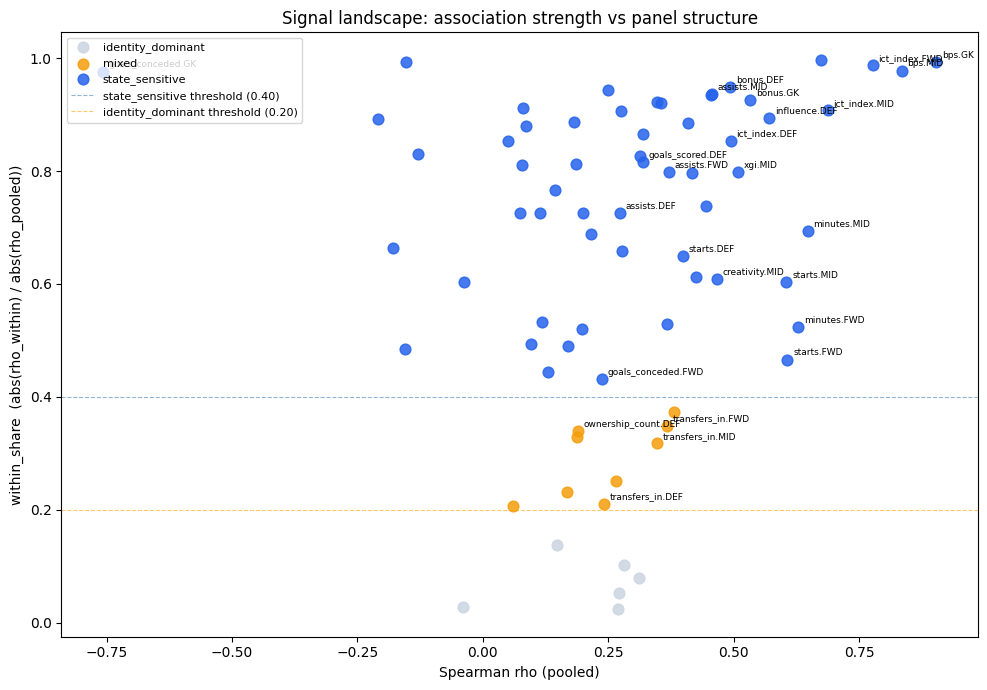

In [17]:
# ── Figure 1: Signal landscape — rho_pooled vs within_share ──────────────────
fig, ax1 = plt.subplots(figsize=(10, 7))

panel_colors = {
    "state_sensitive":   "#2563EB",
    "mixed":             "#F59E0B",
    "identity_dominant": "#CBD5E1",
    "indeterminate":     "#E5E7EB",
}

plot_reg = registry[registry["within_share"].notna() & registry["rho_pooled"].notna()]
for panel_cls, grp in plot_reg.groupby("panel_class"):
    stable = grp[grp.get("decomposition_flag", pd.Series("", index=grp.index)) != "unstable_ratio"]
    unstable_r = grp[grp.get("decomposition_flag", pd.Series("", index=grp.index)) == "unstable_ratio"]
    ax1.scatter(
        stable["rho_pooled"], stable["within_share"],
        color=panel_colors.get(panel_cls, "#9CA3AF"),
        alpha=0.85, s=60, label=panel_cls, zorder=3,
    )
    if not unstable_r.empty:
        ax1.scatter(
            unstable_r["rho_pooled"], unstable_r["within_share"],
            facecolors="none", edgecolors=panel_colors.get(panel_cls, "#9CA3AF"),
            alpha=0.85, s=80, marker="o", linewidths=1.5,
            label=f"{panel_cls} (unstable_ratio)", zorder=3,
        )

cm = registry[registry["association_class"] == "continuous_monotonic"]
for _, row in cm.iterrows():
    if pd.notna(row["rho_pooled"]) and pd.notna(row["within_share"]):
        ax1.annotate(
            f"{row['signal']}.{row['position']}",
            (row["rho_pooled"], row["within_share"]),
            fontsize=6.5, xytext=(4, 3), textcoords="offset points",
        )

ax1.axhline(0.40, color="steelblue", linewidth=0.8, linestyle="--", alpha=0.6,
            label="state_sensitive threshold (0.40)")
ax1.axhline(0.20, color="orange", linewidth=0.8, linestyle="--", alpha=0.6,
            label="identity_dominant threshold (0.20)")
ax1.set_xlabel("Spearman rho (pooled)")
ax1.set_ylabel("within_share  (abs(rho_within) / abs(rho_pooled))")
ax1.set_title("Signal landscape: association strength vs panel structure")
ax1.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()
plt.close()

### Figure 2

`bps` bin profiles across all four positions — reference shape for the strongest `continuous_monotonic` signal.

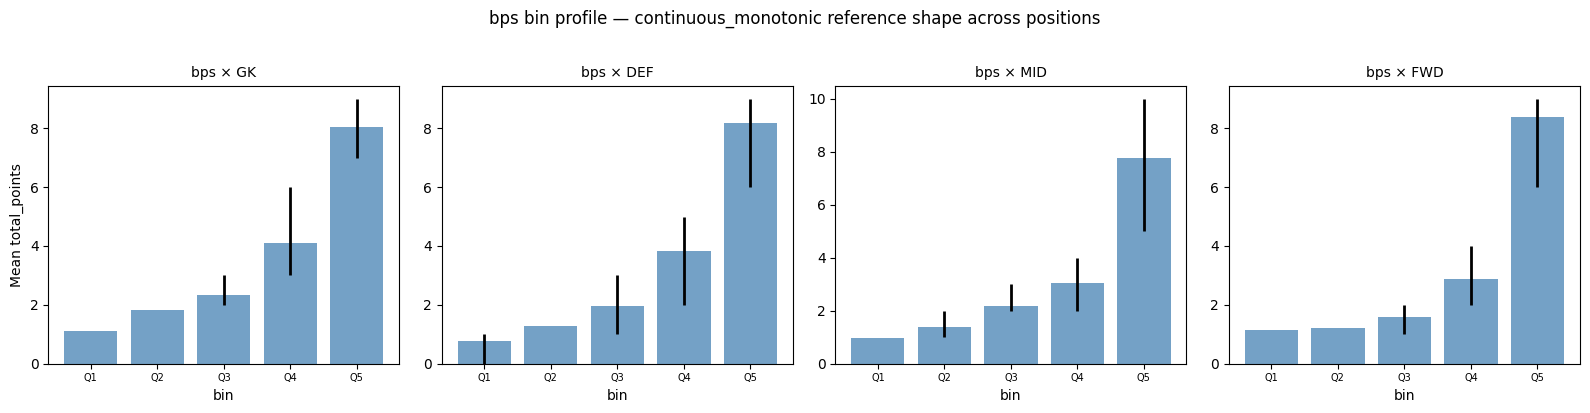

In [18]:
# ── Figure 2: bps bin profiles across all four positions ─────────────────────
positions = ["GK", "DEF", "MID", "FWD"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, pos in zip(axes, positions):
    bs = shape_results.get("bps", {}).get(pos)
    if bs is None:
        ax.set_visible(False)
        continue
    labels = bs["bin"].astype(str)
    ax.bar(labels, bs["mean"], color="steelblue", alpha=0.75)
    ax.vlines(labels, bs["p25"], bs["p75"], color="black", linewidth=2)
    ax.set_title(f"bps × {pos}", fontsize=10)
    ax.set_xlabel("bin")
    ax.tick_params(axis="x", labelsize=7)
    if pos == "GK":
        ax.set_ylabel("Mean total_points")
fig.suptitle("bps bin profile — continuous_monotonic reference shape across positions", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

---
## Summary and Gate Decisions

Aggregates section results, prints governance flags, and generates the `EDA_FINDINGS.md` template. Copy the printed output into `EDA_FINDINGS.md` after review.

In [19]:
print_header("EDA-3 Summary")

summary_df = pd.DataFrame([
    {"question": q, "result": v["result"],
     "detail": str({k: v2 for k, v2 in v.items() if k != "result"})[:120]}
    for q, v in results.items()
])
display(summary_df)

print("\nGeometry breakdown:")
display(registry["relationship_geometry"].value_counts().rename("count").reset_index())

print("\nAssociation class breakdown:")
display(registry["association_class"].value_counts().rename("count").reset_index())

print("\nPanel class breakdown:")
display(registry["panel_class"].value_counts().rename("count").reset_index())

EDA-3 Summary


,question,result,detail
0,META,INFO,"{'n_conditioned': 6082, 'n_active': 8920, 'gw_..."
1,Q4.1,COMPLETE,"{'n_unassessable': 3, 'n_degenerate': 0, 'n_an..."
2,Q4.2,COMPLETE,"{'n_monotonic_input': 60, 'n_reclassified': 13..."
3,Q4.3,CONSTRAINT,"{'n_stable': 38, 'n_moderate_shift': 7, 'n_uns..."
4,Q4.4,CONSTRAINT,"{'n_state_sensitive': 57, 'n_mixed': 9, 'n_ide..."
5,Q4.5,COMPLETE,"{'n_tail_dependent': 0, 'tail_dependent_pairs'..."



Geometry breakdown:


,relationship_geometry,count
0,monotonic_positive,41
1,indeterminate,37
2,non_monotonic,14
3,monotonic_negative,6
4,unassessable,3
5,threshold_positive,2
6,asymmetric_tail,1
7,saturation,1



Association class breakdown:


,association_class,count
0,weak_association,74
1,continuous_monotonic,25
2,unassessable,3
3,upper_tail_concentrated,3



Panel class breakdown:


,panel_class,count
0,state_sensitive,57
1,indeterminate,33
2,mixed,9
3,identity_dominant,6


### Governance flags

Prints constraint flags for downstream consumers. Generates the `EDA_FINDINGS.md` template — copy the printed output after review.

In [21]:
print("Governance flags:")
id_dom   = registry[registry["panel_class"] == "identity_dominant"]
unassess = registry[registry["association_class"] == "unassessable"]
lc       = registry[registry.get("low_confidence", pd.Series(False, index=registry.index)) == True]
ur       = registry[registry.get("decomposition_flag", pd.Series("", index=registry.index)) == "unstable_ratio"]
print(f"  identity_dominant:    {len(id_dom)} pairs")
print(f"  unassessable:         {len(unassess)} cells (support failure blocked geometry)")
print(f"  low_confidence:       {len(lc)} pairs (monotonic but confidence {MONO_CONF_LOW:.0%}–{MONO_CONF_HIGH:.0%})")
print(f"  unstable_ratio:       {len(ur)} pairs (within_share > 1.0; panel_class indeterminate)")

if not lc.empty:
    print("\n  Low-confidence monotonic pairs:")
    for _, r in lc.iterrows():
        mc = r.get("monotonicity_confidence")
        mc_str = f"{mc:.2f}" if pd.notna(mc) else "n/a"
        print(f"    {r['signal']} x {r['position']}  confidence={mc_str}")

print("\n" + "=" * 88)
print("Template for EDA_FINDINGS.md (copy after review):")
print("=" * 88 + "\n")
for line in build_findings_template(results, registry):
    print(line)

Governance flags:
  identity_dominant:    6 pairs
  unassessable:         3 cells (support failure blocked geometry)
  low_confidence:       7 pairs (monotonic but confidence 60%–80%)
  unstable_ratio:       33 pairs (within_share > 1.0; panel_class indeterminate)

  Low-confidence monotonic pairs:
    fdr_avg x MID  confidence=0.70
    fdr_max x MID  confidence=0.74
    purchase_price x DEF  confidence=0.66
    transfers_out x FWD  confidence=0.64
    xa x MID  confidence=0.76
    xgc x MID  confidence=0.65
    yellow_cards x MID  confidence=0.62

Template for EDA_FINDINGS.md (copy after review):

## EDA-3 — Signal-Target Relationship Structure

Primary output: research/eda/findings/eda_03_joint_registry.csv
Registry rows: 105  (signals × positions analyzed)

### Primary findings

Geometry classification:
  asymmetric_tail: 1 signal-position pairs
  indeterminate: 37 signal-position pairs
  monotonic_negative: 6 signal-position pairs
  monotonic_positive: 41 signal-position pairs
  no